# DATA 266 — Homework 3
## Prompt Engineering and Attention Mechanisms

References: `Prompt_Engineering.ipynb` and `Demo_3_Attention_Mechanism.ipynb` (professor-provided demos).

## Personal Parameters and Reproducibility

In [1]:
import random
import numpy as np
import torch

SID4 = 9486
SEED = 9486
SLICE = 486
HP_ID = 0
CLS_A = 6
CLS_B = 0

print(f"SID4  = {SID4}")
print(f"SEED  = {SEED}")
print(f"SLICE = {SLICE}")
print(f"HP_ID = {HP_ID}")
print(f"CLS_A = {CLS_A}")
print(f"CLS_B = {CLS_B}")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

SID4  = 9486
SEED  = 9486
SLICE = 486
HP_ID = 0
CLS_A = 6
CLS_B = 0


## Part 1: Prompt Engineering Techniques

This section implements six prompting techniques — Zero-Shot, Few-Shot, Chain-of-Thought, Zero-Shot CoT,
Meta-Prompting, and Tree of Thoughts — with two worked examples each. Every prompt is called through code
using the same LangChain + `ChatGoogleGenerativeAI` pattern (`set_params` / `get_completion`) shown in the
professor's `Prompt_Engineering.ipynb`, so no screenshots or manually typed chat transcripts are used.

> **Execution status: NOT executed in this run.** This entire Part 1 section requires Google Colab (for the `google.colab.userdata` secret) and a configured `GOOGLE_API_KEY`. It was left unexecuted here rather than run with missing credentials, per the assignment instructions. Run these cells in Colab to populate their outputs; Part 2 below does not depend on anything in this section and was executed and verified independently, locally.

> **Execution status: NOT executed in this run.** This entire Part 1 section requires Google Colab (for the `google.colab.userdata` secret) and a configured `GOOGLE_API_KEY`. It was left unexecuted here rather than run with missing credentials, per the assignment instructions. Run these cells in Colab to populate their outputs; Part 2 below does not depend on anything in this section and was executed and verified independently, locally.

### 1.0 Setup — Libraries, API Key, and Helper Functions

In [2]:
!pip install --upgrade langchain google-genai langchain-google-genai
!pip install --upgrade python-dotenv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.4/262.4 kB 11.7 MB/s eta 0:00:00
  Attempting uninstall: google-auth
    Found existing installation: google-auth 2.49.0
    Uninstalling google-auth-2.49.0:
      Successfully uninstalled google-auth-2.49.0
  Attempting uninstall: google-genai
    Found existing installation: google-genai 2.12.1
    Uninstalling google-genai-2.12.1:
      Successfully uninstalled google-genai-2.12.1
  Attempting uninstall: langchain
    Found existing installation: langchain 1.3.18
    Uninstalling langchain-1.3.18:
      Successfully uninstalled langchain-1.3.18
ERROR: pip's dependency resolver does not currently take into account all the packa

In [3]:
import os
import IPython
from dotenv import load_dotenv
from langchain.messages import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI

**Configuration required.** The next cell expects a Colab secret named `GOOGLE_API_KEY` — the same secret
already configured for `Prompt_Engineering.ipynb`. No key is hard-coded here. This is the only cell in this
section that depends on your environment/secrets; every prompt cell below it only depends on `get_completion`
having a valid API key configured through this cell.

_Not run in this execution: no `GOOGLE_API_KEY` / Colab environment was available here._

_Not run in this execution: no `GOOGLE_API_KEY` / Colab environment was available here._

In [5]:
from google.colab import userdata

# Reuses the same Colab secret configured for Prompt_Engineering.ipynb.
api_key = userdata.get('GOOGLE_API_KEY')
os.environ["GOOGLE_API_KEY"] = api_key

In [32]:
MODEL_NAME = "gemma-4-31b-it"


def set_params(
    model=MODEL_NAME,
    temperature=0,
    max_tokens=512,
    frequency_penalty=0,
    presence_penalty=0,
):
    """set ai parameters"""
    return {
        'model': model,
        'temperature': temperature,
        'max_tokens': max_tokens,
        'frequency_penalty': frequency_penalty,
        'presence_penalty': presence_penalty,
    }


def get_completion(params, messages):
    """GET completion from ai api"""
    model = ChatGoogleGenerativeAI(
        model=params['model'],
        temperature=params['temperature'],
        max_output_tokens=params['max_tokens'],
        frequency_penalty=params['frequency_penalty'],
        presence_penalty=params['presence_penalty'],
    )
    response = model.invoke(messages)
    return response


def run_prompt(label, prompt, params=None):
    """Send one prompt through get_completion and display the prompt and the response."""
    params = params or set_params()
    messages = [HumanMessage(content=prompt)]
    response = get_completion(params, messages)

    IPython.display.display(IPython.display.Markdown(f"**{label} — Prompt:**\n```\n{prompt}\n```"))
    IPython.display.display(IPython.display.Markdown(f"**{label} — Response:**\n\n{response.text}"))
    return response

### 1. Zero-Shot Prompting

The model receives only a direct instruction or question — no examples and no requested reasoning steps.
It must rely entirely on knowledge learned during pretraining. Zero-shot prompts are the fastest to write,
but performance depends heavily on how clearly the task itself is phrased.

In [7]:
zero_shot_math_prompt = """What is 17 multiplied by 6? Answer with only the number."""

run_prompt("Zero-Shot — Math", zero_shot_math_prompt)

**Zero-Shot — Math — Prompt:**
```
What is 17 multiplied by 6? Answer with only the number.
```

**Zero-Shot — Math — Response:**

102

AIMessage(content=[{'type': 'thinking', 'thinking': 'The user wants to know the result of 17'}, {'type': 'thinking', 'thinking': 'The user wants to know the result of 17 multiplied by 6.\n17 * 6 = (10 * 6) + (7 * 6) = 60 + 42 = 102.\nThe user requested "only the number".'}, {'type': 'text', 'text': '102'}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemma-4-31b-it', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0a3bc-37e4-7d30-9fb9-d55a13d76985-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 74, 'total_tokens': 91, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 71}})

In [8]:
zero_shot_text_prompt = """Classify the sentiment of this sentence as positive, negative, or neutral.

Sentence: "The flight was delayed for six hours and no one apologized."

Sentiment:"""

run_prompt("Zero-Shot — Text Classification", zero_shot_text_prompt)

**Zero-Shot — Text Classification — Prompt:**
```
Classify the sentiment of this sentence as positive, negative, or neutral.

Sentence: "The flight was delayed for six hours and no one apologized."

Sentiment:
```

**Zero-Shot — Text Classification — Response:**

Negative

AIMessage(content=[{'type': 'thinking', 'thinking': '*   Sentence: "The flight was delayed for six hours and no one apologized."\n    *   Task: Classify sentiment as positive, negative, or neutral.\n\n    *   "flight was delayed for six hours": This is a negative experience (loss of time, inconvenience).\n    *   "no one apologized": This is a negative experience (lack of customer service, feeling ignored/disrespected).\n\n    *   Both parts of the sentence describe negative events.\n    *   The overall tone is one of frustration and dissatisfaction.\n\n    *   Positive? No.\n    *   Neutral? No.\n    *   Negative? Yes.'}, {'type': 'text', 'text': 'Negative'}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemma-4-31b-it', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0a3bd-12ef-7d41-889f-d6a1f87a4393-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 35, 'output_tokens': 136, 'total_tokens': 171, 'inpu

### 2. Few-Shot Prompting

The prompt includes a small number of worked input/output pairs before the new query. The examples show
only final answers, not reasoning, so the model is expected to match the demonstrated pattern rather than
derive it from an explicit instruction.

In [9]:
few_shot_math_prompt = """The even numbers in this group add up to an odd number: 9, 4, 15, 8, 3.
A: False

The even numbers in this group add up to an odd number: 22, 7, 6, 19, 14.
A: False

The even numbers in this group add up to an odd number: 46, 9, 8, 6, 4.
A:"""

run_prompt("Few-Shot — Math Pattern", few_shot_math_prompt)

**Few-Shot — Math Pattern — Prompt:**
```
The even numbers in this group add up to an odd number: 9, 4, 15, 8, 3.
A: False

The even numbers in this group add up to an odd number: 22, 7, 6, 19, 14.
A: False

The even numbers in this group add up to an odd number: 46, 9, 8, 6, 4.
A:
```

**Few-Shot — Math Pattern — Response:**

False

AIMessage(content=[{'type': 'thinking', 'thinking': '*   '}, {'type': 'thinking', 'thinking': '*   Input: A list of numbers (46, 9, 8, 6, 4).\n    *   Task: Determine if the sum of the even numbers in this group is an odd number.\n    *   Format: True/False (following the pattern of the previous examples).\n\n    *   Numbers: 46, 9, 8, 6, 4.\n    *   Even numbers: 46, 8, 6, 4.\n\n    *   46 + 8 = 54\n    *   54 + 6 = 60\n    *   60 + 4 = 64\n\n    *   The sum is 64.\n    *   Is 64 an odd number? No, it is even.\n\n    *   The statement "The even numbers in this group add up to an odd number" is False.'}, {'type': 'text', 'text': 'False'}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemma-4-31b-it', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0a3be-2c65-7343-a0b4-012a91082807-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 103, 'output_tokens': 200, 'total_tokens': 303, 'input_token_details': {'c

In [10]:
few_shot_text_prompt = """Classify each sentence into one category: Sports, Technology, or Food.

Sentence: The team scored a last-minute goal to win the championship.
Category: Sports

Sentence: The new smartphone features a faster processor and a larger battery.
Category: Technology

Sentence: The chef added fresh basil to the simmering tomato sauce.
Category: Food

Sentence: The company released a software update that fixed several security bugs.
Category:"""

run_prompt("Few-Shot — Text Classification", few_shot_text_prompt)

**Few-Shot — Text Classification — Prompt:**
```
Classify each sentence into one category: Sports, Technology, or Food.

Sentence: The team scored a last-minute goal to win the championship.
Category: Sports

Sentence: The new smartphone features a faster processor and a larger battery.
Category: Technology

Sentence: The chef added fresh basil to the simmering tomato sauce.
Category: Food

Sentence: The company released a software update that fixed several security bugs.
Category:
```

**Few-Shot — Text Classification — Response:**

Technology

AIMessage(content=[{'type': 'thinking', 'thinking': '*   Task: Classify sentences into one of three categories: Sports, Technology, or Food.\n    *   Input: A series of examples (few-shot prompting) and a final sentence to classify.\n    *   Target sentence: "The company released a software update that fixed several security bugs."\n\n    *   "The company released a software update that fixed several security bugs."\n    *   Keywords: "company", "software update", "security bugs".\n    *   Context: Software and security are core components of technology.\n\n    *   Sports? No.\n    *   Technology? Yes.\n    *   Food? No.'}, {'type': 'text', 'text': 'Technology'}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemma-4-31b-it', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0a3be-e872-7b53-aa7e-9dbdd8da6437-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 91, 'output_tokens': 137, 'total_tokens': 228, 'i

### 3. Chain-of-Thought (CoT) Prompting

Like few-shot prompting, the exemplars precede a new query — but here each exemplar also shows the
intermediate reasoning steps, not just the final answer. Demonstrating *how* to reach an answer, not only
*what* the answer is, is intended to make the model produce its own explicit reasoning before answering.

In [11]:
cot_math_prompt = """The even numbers in this group add up to an odd number: 9, 4, 15, 8, 3.
A: Adding all the even numbers (4, 8) gives 12. The answer is False.

The even numbers in this group add up to an odd number: 22, 7, 6, 19, 14.
A: Adding all the even numbers (22, 6, 14) gives 42. The answer is False.

The even numbers in this group add up to an odd number: 46, 9, 8, 6, 4.
A:"""

run_prompt("Chain-of-Thought — Math", cot_math_prompt)

**Chain-of-Thought — Math — Prompt:**
```
The even numbers in this group add up to an odd number: 9, 4, 15, 8, 3.
A: Adding all the even numbers (4, 8) gives 12. The answer is False.

The even numbers in this group add up to an odd number: 22, 7, 6, 19, 14.
A: Adding all the even numbers (22, 6, 14) gives 42. The answer is False.

The even numbers in this group add up to an odd number: 46, 9, 8, 6, 4.
A:
```

**Chain-of-Thought — Math — Response:**

Adding all the even numbers (46, 8, 6, 4) gives 64. The answer is False.

AIMessage(content=[{'type': 'thinking', 'thinking': '*   Input: A list of numbers (46, 9, 8, 6, 4).\n    *   Task: Determine if the sum of the even numbers in the group is an odd number.\n    *   Format: Follow the pattern provided in the examples.\n\n    *   Numbers: 46, 9, 8, 6, 4.\n    *   Even numbers: 46, 8, 6, 4.\n    *   Sum: 46 + 8 + 6 + 4 = 64.\n    *   Is 64 odd? No, it is even.\n\n    *   Example 1: "Adding all the even numbers (4, 8) gives 12. The answer is False."\n    *   Example 2: "Adding all the even numbers (22, 6, 14) gives 42. The answer is False."\n    *   My response: "Adding all the even numbers (46, 8, 6, 4) gives 64. The answer is False."'}, {'type': 'text', 'text': 'Adding all the even numbers (46, 8, 6, 4) gives 64. The answer is False.'}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemma-4-31b-it', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0a3bf-6328-7f10-bba2-2283204521ca-0', tool_calls=[],

In [12]:
cot_logic_prompt = """Question: All birds have feathers. A robin is a bird. Does a robin have feathers?
A: All birds have feathers. A robin is a bird, so a robin belongs to the group "birds." Therefore, a robin has feathers. The answer is Yes.

Question: All squares have four equal sides. A stop sign is not a square. Can we conclude from that first statement that a stop sign has four equal sides?
A:"""

run_prompt("Chain-of-Thought — Logic", cot_logic_prompt)

**Chain-of-Thought — Logic — Prompt:**
```
Question: All birds have feathers. A robin is a bird. Does a robin have feathers?
A: All birds have feathers. A robin is a bird, so a robin belongs to the group "birds." Therefore, a robin has feathers. The answer is Yes.

Question: All squares have four equal sides. A stop sign is not a square. Can we conclude from that first statement that a stop sign has four equal sides?
A:
```

**Chain-of-Thought — Logic — Response:**

All squares have four equal sides. A stop sign is not a square, so the rule about squares does not apply to it. The first statement tells us nothing about objects that are not squares. Therefore, we cannot conclude that a stop sign has four equal sides

AIMessage(content=[{'type': 'thinking', 'thinking': '*   Question 1: "All birds have feathers. A robin is a bird. Does a robin have feathers?"\n    *   Answer 1: "All birds have feathers. A robin is a bird, so a robin belongs to the group \'birds.\' Therefore, a robin has feathers. The answer is Yes."\n    *   Question 2: "All squares have four equal sides. A stop sign is not a square. Can we conclude from that first statement that a stop sign has four equal sides?"\n\n    *   Premise 1: All squares have four equal sides. (If X is a square, then X has four equal sides).\n    *   Premise 2: A stop sign is not a square. (X is not a square).\n    *   Conclusion to evaluate: Does a stop sign have four equal sides?\n\n    *   This is a classic logical fallacy known as "denying the antecedent."\n    *   Structure: If P, then Q. Not P. Therefore, not Q (or in this case, asking if Q is true).\n    *   Just because all squares have four equal sides doesn\'t mean *only* squares have four equal s

### 4. Zero-Shot Chain-of-Thought

No worked examples are provided at all. A single new question is appended with a short trigger phrase —
"Let's think step by step" — which nudges the model to generate its own reasoning trace before answering,
without ever having seen a demonstration.

In [13]:
zero_shot_cot_math_prompt = """A bakery had 94 cupcakes. It sold 8 in the morning, baked 6 more in the afternoon, and then donated 4 to a school fundraiser. How many cupcakes does the bakery have now?

Let's think step by step."""

run_prompt("Zero-Shot CoT — Math", zero_shot_cot_math_prompt)

**Zero-Shot CoT — Math — Prompt:**
```
A bakery had 94 cupcakes. It sold 8 in the morning, baked 6 more in the afternoon, and then donated 4 to a school fundraiser. How many cupcakes does the bakery have now?

Let's think step by step.
```

**Zero-Shot CoT — Math — Response:**

Here is the step-by-step breakdown:

1. **Start with the initial amount:** The bakery had 94 cupcakes.
2. **Subtract the cupcakes sold:** 94 - 8 = 86 cupcakes.
3. **Add the cupcakes baked:** 86 + 6 = 92 cupcakes.
4. **Subtract the cupcakes donated:** 92 - 4 = 88 cupcakes.

The bakery now has **88** cupcakes.

AIMessage(content=[{'type': 'thinking', 'thinking': '*   Initial number of cupcakes: 94\n    *   Sold in the morning: 8 (decrease)\n    *   Baked in the afternoon: 6 (increase)\n    *   Donated to a fundraiser: 4 (decrease)\n\n    *   Step'}, {'type': 'thinking', 'thinking': '*   Initial number of cupcakes: 94\n    *   Sold in the morning: 8 (decrease)\n    *   Baked in the afternoon: 6 (increase)\n    *   Donated to a fundraiser: 4 (decrease)\n\n    *   Step 1: Subtract the cupcakes sold in the morning from the initial amount.\n    *   Step 2: Add the cupcakes baked in the afternoon to the current total.\n    *   Step 3: Subtract the cupcakes donated to the fundraiser from the current total.\n\n    *   Step 1: 94 - 8 = 86\n    *   Step 2: 86 + 6 = 92\n    *   Step 3: 92 - 4 = 88\n\n    *   Start: 94\n    *   Sold 8: 94 - 8 = 86\n    *   Baked 6: 86 + 6 = 92\n    *   Donated 4: 92 - 4 = 88\n    *   Final answer: 88'}, {'type': 'text', 'text': 'Here is the step-by-step breakdown:\n\n1. 

In [14]:
zero_shot_cot_logic_prompt = """All Zorbs are Flurps. All Flurps are Wibbles. Is every Zorb definitely a Wibble?

Let's think step by step."""

run_prompt("Zero-Shot CoT — Logic", zero_shot_cot_logic_prompt)

**Zero-Shot CoT — Logic — Prompt:**
```
All Zorbs are Flurps. All Flurps are Wibbles. Is every Zorb definitely a Wibble?

Let's think step by step.
```

**Zero-Shot CoT — Logic — Response:**

Here is the step-by-step logic:

1.  **Analyze the first statement:** "All Zorbs are Flurps." This means that if something is a Zorb, it must automatically be a Flurp.
2.  **Analyze the second statement:** "All Flurps are Wibbles." This means that if something is a Flurp, it must automatically be a Wibble.
3.  **Connect the two:** Since every Zorb is a Flurp, and every Flurp is a Wibble, the Zorb inherits the property of being a Wibble through its status as a Flurp.

**Conclusion:** Yes, every Zorb is definitely a Wibble.

AIMessage(content=[{'type': 'thinking', 'thinking': '*   Premise 1: All Zorbs are Flurps.\n    *   Premise 2: All Flurps are Wibbles.\n    *   Question: Is every Zorb definitely a Wibble?\n\n    *   Premise 1: $Z \\subseteq F$ (Zorbs are a subset of Flurps).\n    *   Premise 2: $F \\subseteq W$ (Flurps are a subset of Wibbles).\n\n    *   If $Z$ is inside $F$, and $F$ is inside $W$, then $Z$ must be inside $W$.\n    *   Transitive property: If $A \\implies B$ and $B \\implies C$, then $A \\implies C$.\n\n    *   Step 1: Start with a Zorb.\n    *   Step 2: Since all Zorbs are Flurps, that Zorb must be a Flurp.\n    *   Step 3: Since all Flurps are Wibbles, and that Zorb is a Flurp, that Zorb must also be a Wibble.\n    *   Conclusion: Yes.'}, {'type': 'text', 'text': 'Here is the step-by-step logic:\n\n1.  **Analyze the first statement:** "All Zorbs are Flurps." This means that if something is a Zorb, it must automatically be a Flurp.\n2.  **Analyze the second statement:** "All Flurps a

### 5. Meta-Prompting

Rather than asking the model to solve one specific instance of a problem, the prompt asks it to produce a
general strategy, checklist, or template that applies to an entire class of problems. The model reasons
about *how to approach* the task rather than about a particular answer.

In [15]:
meta_prompt_math = """You are an expert prompt engineer. Write a short, general step-by-step strategy (not the answer to any specific example) that could be used to solve any problem of this form:

"Given a list of numbers, determine whether the sum of the even numbers in the list is odd or even."

Describe the reasoning method only. Do not solve a specific list."""

run_prompt("Meta-Prompting — Math Strategy", meta_prompt_math)

**Meta-Prompting — Math Strategy — Prompt:**
```
You are an expert prompt engineer. Write a short, general step-by-step strategy (not the answer to any specific example) that could be used to solve any problem of this form:

"Given a list of numbers, determine whether the sum of the even numbers in the list is odd or even."

Describe the reasoning method only. Do not solve a specific list.
```

**Meta-Prompting — Math Strategy — Response:**



AIMessage(content=[{'type': 'thinking', 'thinking': '\n*   Goal: Create a general step-by-step strategy (prompt engineering style) to solve a specific type of problem.\n*   Problem Type: "Given a list of numbers, determine whether the sum of the even numbers in the list is odd or even."\n*   Constraint 1: Short and general.\n*   Constraint 2: Reasoning method only (no specific examples/answers).\n*   Role: Expert Prompt Engineer.\n\n    *   Input: A list of numbers.\n    *   Filter: Identify even numbers.\n    *   Operation: Sum those even numbers.\n    *   Evaluation: Determine if the result is odd or even.\n\n    *   *Step 1: Filtering.* Look at each number. Is it even? If yes, keep it. If no, ignore it.\n    *   *Step 2: Summation.* Add all the kept numbers together.\n    *   *Step 3: Parity Check.* Check if the total is divisible by 2.\n\n    *   *Wait, is there a shortcut?*\n    *   The sum of any number of even numbers is *always* even.\n    *   Wait, let me double-check: $2 + 4 

In [16]:
meta_prompt_text = """You are an expert prompt engineer. Write a short, general checklist an AI assistant should follow to classify a customer review as positive, negative, or neutral. Include the kinds of words, phrases, or context clues it should look for.

Describe the general checklist only. Do not classify any specific review yet."""

run_prompt("Meta-Prompting — Classification Checklist", meta_prompt_text)

**Meta-Prompting — Classification Checklist — Prompt:**
```
You are an expert prompt engineer. Write a short, general checklist an AI assistant should follow to classify a customer review as positive, negative, or neutral. Include the kinds of words, phrases, or context clues it should look for.

Describe the general checklist only. Do not classify any specific review yet.
```

**Meta-Prompting — Classification Checklist — Response:**

### Sentiment Classification Checklist

**1. Keyword Identification**
Scan the text for high-intensity adjectives and adverbs that signal a clear emotional state:
*   **Positive:** *Excellent, amazing, love, perfect, best, highly, impressed, seamless, fantastic.*
*   **Negative:** *Terrible, awful, hate, worst, disappointed, broken, waste, poor, frustrating.*
*   **Neutral:** *Average, okay, fine

AIMessage(content=[{'type': 'thinking', 'thinking': '\n*   Role: Expert Prompt Engineer.\n*   Task: Write a short, general checklist for an AI assistant to classify customer reviews (Positive, Negative, Neutral).\n*   Requirements:\n    *   Include words, phrases, and context clues.\n    *   Describe the general checklist *only*.\n    *   Do *not* classify any specific reviews.\n\n    *   *Positive:* Satisfaction, praise, recommendation, excitement.\n    *   *Negative:* Frustration, disappointment, complaints, warnings.\n    *   *Neutral:* Factual descriptions, mixed feelings, indifference, "it\'s okay."\n\n    *   *Step 1: Sentiment Analysis (Keywords).* Look for adjectives and adverbs.\n    *   *Step 2: Contextual Clues (Phrasing).* Look for comparisons or specific outcomes.\n    *   *Step 3: Tone/Intensity.* Look for punctuation or capitalization.\n    *   *Step 4: Conflict Resolution (Mixed Sentiment).* How to handle "but" or "however."\n    *   *Step 5: Final Classification.* Assi

### 6. Tree of Thoughts (ToT)

The prompt asks the model to explore more than one reasoning path or interpretation for the same problem,
solve each one, compare them, and then converge on a final answer — instead of committing to a single
linear chain of reasoning up front.

In [17]:
tot_math_prompt = """I had 12 oranges. I gave 3 oranges to my neighbor and 2 to my cousin. Later, I bought 9 more oranges and ate 4. How many oranges do I have now?

Let's think step by step using a tree of thought approach:

### Step 1: Identify possible solution paths
1. **Path A (Subtract first)**
   - Start with 12 oranges.
   - Subtract the oranges given away first, then add the newly bought oranges.
   - Finally, subtract the oranges eaten.

2. **Path B (Add first)**
   - Start with 12 oranges.
   - Add the newly bought oranges first, then subtract the oranges given away.
   - Finally, subtract the oranges eaten.

### Step 2: Solve each path and compare
Compute the final total using both paths, confirm they agree, and state the result.

Final Answer:"""

run_prompt("Tree of Thoughts — Math", tot_math_prompt)

**Tree of Thoughts — Math — Prompt:**
```
I had 12 oranges. I gave 3 oranges to my neighbor and 2 to my cousin. Later, I bought 9 more oranges and ate 4. How many oranges do I have now?

Let's think step by step using a tree of thought approach:

### Step 1: Identify possible solution paths
1. **Path A (Subtract first)**
   - Start with 12 oranges.
   - Subtract the oranges given away first, then add the newly bought oranges.
   - Finally, subtract the oranges eaten.

2. **Path B (Add first)**
   - Start with 12 oranges.
   - Add the newly bought oranges first, then subtract the oranges given away.
   - Finally, subtract the oranges eaten.

### Step 2: Solve each path and compare
Compute the final total using both paths, confirm they agree, and state the result.

Final Answer:
```

**Tree of Thoughts — Math — Response:**

### Step 1: Identify possible solution paths
1. **Path A (Subtract first)**
   - Start with 12 oranges.
   - Subtract the oranges given away (3 to neighbor, 2 to cousin).
   - Add the newly bought oranges (9).
   - Subtract the oranges eaten (4).

2. **Path B (Add first)**
   - Start with 12 oranges.
   - Add the newly bought oranges (9).
   - Subtract the oranges given away (3 to neighbor, 2 to cousin).
   - Subtract the oranges eaten (4).

### Step 2: Solve each path and compare

**Solving Path A:**
- Initial: 12
- Given away: $12 - 3 - 2 = 7$
- Bought: $7 + 9 = 16$
- Eaten: $16 - 4 = 12$
- **Total: 12**

**Solving Path B:**
- Initial: 12
- Bought: $12 + 9 =

AIMessage(content=[{'type': 'thinking', 'thinking': '*   Initial amount: 12 oranges.\n    *   Action 1: Give 3 to neighbor.\n    *   Action 2: Give 2 to cousin.\n    *   Action 3: Buy 9 more.\n    *   Action 4: Eat 4.\n    *   Goal: Find the final number of oranges.\n\n    *   **Path A (Subtract first):**\n        *   Start: 12\n        *   Subtract given away: $12 - 3 - 2 = 7$\n        *   Add bought: $7 + 9 = 16$\n        *   Subtract eaten: $16 - 4 = 12$\n\n    *   **Path B (Add first):**\n        *   Start: 12\n        *   Add bought: $12 + 9 = 21$\n        *   Subtract given away: $21 - 3 - 2 = 16$\n        *   Subtract eaten: $16 - 4 = 12$\n\n    *   Path A result: 12\n    *   Path B result: 12\n    *   The results match.\n\n    *   Follow the requested "Tree of Thought" structure.'}, {'type': 'text', 'text': '### Step 1: Identify possible solution paths\n1. **Path A (Subtract first)**\n   - Start with 12 oranges.\n   - Subtract the oranges given away (3 to neighbor, 2 to cousin)

In [18]:
tot_logic_prompt = """A farmer has 17 sheep. All but 9 run away. How many sheep does the farmer have left?

Let's think step by step using a tree of thought approach:

### Step 1: Identify possible interpretations
1. **Path A (Literal subtraction)**
   - Interpret "all but 9 run away" as "17 minus 9 sheep run away."
   - Compute how many remain under this reading.

2. **Path B (Idiomatic reading)**
   - Interpret "all but 9 run away" as "every sheep except 9 runs away," meaning 9 stay behind.
   - Compute how many remain under this reading.

### Step 2: Compare both paths
Decide which interpretation matches standard English usage and state the final number of sheep left.

Final Answer:"""

run_prompt("Tree of Thoughts — Logic", tot_logic_prompt)

**Tree of Thoughts — Logic — Prompt:**
```
A farmer has 17 sheep. All but 9 run away. How many sheep does the farmer have left?

Let's think step by step using a tree of thought approach:

### Step 1: Identify possible interpretations
1. **Path A (Literal subtraction)**
   - Interpret "all but 9 run away" as "17 minus 9 sheep run away."
   - Compute how many remain under this reading.

2. **Path B (Idiomatic reading)**
   - Interpret "all but 9 run away" as "every sheep except 9 runs away," meaning 9 stay behind.
   - Compute how many remain under this reading.

### Step 2: Compare both paths
Decide which interpretation matches standard English usage and state the final number of sheep left.

Final Answer:
```

**Tree of Thoughts — Logic — Response:**

### Step 1: Identify possible interpretations
1. **Path A (Literal subtraction)**
   - Interpret "all but 9 run away" as a subtraction problem where 9 is the number that left.
   - Calculation: $17 - 9 = 8$.
   - Result: 8 sheep remain.

2. **Path B (Idiomatic reading)**
   - Interpret "all but 9 run away" as "every sheep except for 9 ran away."
   - Logic: If all sheep left except for 9, then 9 sheep are the ones that stayed.
   - Result: 9 sheep remain.

### Step 2: Compare both paths
In standard English, the phrase "all but [number]" is an idiomatic expression meaning "everything except [number]." Therefore, if all but 9 sheep ran away, it means that 9 sheep did not run away and are still with the farmer. Path A is a common misinterpretation of the phrasing, while Path B correctly identifies the meaning of the sentence.

Final Answer: 9

AIMessage(content=[{'type': 'thinking', 'thinking': '*   Initial number of sheep: 17.\n    *   Event: "All but 9 run away."\n    *   Question: "How many sheep does the farmer have left?"\n\n    *   *Path A (Literal subtraction):*\n        *   Assumption: "All but 9" means 9 sheep ran away.\n        *   Calculation: $17 - 9 = 8$.\n        *   Result: 8 sheep left.\n\n    *   *Path B (Idiomatic reading):*\n        *   Assumption: "All but 9" means everyone *except* 9 ran away.\n        *   Logic: If everyone except 9 left, then 9 are the ones who stayed.\n        *   Calculation: The number remaining is explicitly stated as 9.\n        *   Result: 9 sheep left.\n\n    *   In English, the phrase "all but [number]" means "everything except [number]."\n    *   Example: "All but one survived" means only one died; everyone else survived.\n    *   Therefore, "All but 9 run away" means 9 did *not* run away.\n\n    *   The farmer has 9 sheep left.'}, {'type': 'text', 'text': '### Step 1: Identif

## Comparison of Prompting Techniques

| Technique | Structure | Reasoning Behavior | Strengths | Weaknesses |
| --- | --- | --- | --- | --- |
| Zero-Shot | Single instruction/question; no examples, no reasoning request | Answers directly from the instruction alone, relying on pretrained knowledge | Shortest prompt to write; fast; adequate for simple, well-known tasks | No guidance on format or reasoning; brittle on multi-step or ambiguous tasks |
| Few-Shot | Several input/output pairs, then a new query; examples show answers only | Pattern-matches the demonstrated input-to-output mapping | Helps the model infer task format/labels without an explicit instruction; effective for classification-style tasks | Examples without reasoning may not transfer to tasks that need multi-step arithmetic or logic |
| Chain-of-Thought | Few-shot examples that also show intermediate reasoning steps, then a new query | Guided to produce an explicit step-by-step reasoning trace before the final answer | Makes intermediate steps explicit and checkable; well suited to arithmetic/logic tasks | Longer prompt; exemplar reasoning must be hand-written and can bias the model toward one (possibly wrong) reasoning style |
| Zero-Shot CoT | One new question plus a short trigger phrase ("Let's think step by step"); no exemplars | Generates its own step-by-step reasoning without ever seeing a worked example | No exemplars to write; applies to almost any question with one added sentence | Less controllable than CoT with exemplars; reasoning quality depends entirely on the trigger phrase and base model |
| Meta-Prompting | Asks for a general strategy/checklist for a class of problems, not a specific answer | Reasons about the reasoning process itself rather than about one concrete instance | Produces a reusable strategy/template; useful for designing further prompts | Does not solve the concrete task by itself; a follow-up prompt is needed to apply the strategy |
| Tree of Thoughts | Explicitly lists multiple candidate reasoning paths/interpretations, asks the model to solve and compare them, then converge | Explores more than one line of reasoning before committing to a final answer | Can surface and correct a wrong interpretation (as in the sheep example) that a single linear chain might commit to | Longest, most structured prompt; still relies on the model correctly executing each branch rather than a real search algorithm |

**Note:** This table describes the general structure and documented behavior of each technique. Any claim that
one technique produced a *better* answer than another for a specific example should be checked directly against
the prompt/response pairs printed above once this notebook is executed in Colab — the parity and sheep-count
examples in particular are built so that correctness can be verified from the model's own output rather than
assumed in advance.

## Part 2: Self-Attention and Causal Masking (From Scratch)

This section follows `Demo_3_Attention_Mechanism.ipynb` and implements single-head scaled dot-product
self-attention entirely from basic PyTorch components. Using the fixed dataset given for this assignment, we:

- tokenize the text at the word level
- build the vocabulary and token-to-index mappings
- learn token embeddings from scratch (`nn.Embedding`)
- learn trainable Q, K, V projections (`nn.Linear`)
- compute attention scores explicitly (`QKᵀ / sqrt(d_k)`) and apply softmax
- train with a next-token (autoregressive) objective
- compute the full-sequence attention matrix after training
- visualize attention with and without a causal mask
- verify with assertions that the causal mask blocks all future-token attention

**Constraints (matching the assignment):** no `nn.MultiheadAttention`, no `nn.Transformer`, no HuggingFace
transformer classes, no positional encoding, and no multi-head attention or transformer blocks — only
`nn.Embedding`, `nn.Linear`, explicit matrix multiplication, softmax, and a loss function.

In [19]:
import math
import re
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


### 2.1 Word-Level Tokenization

The raw text is lowercased and split into word tokens using a simple regular expression that keeps runs
of letters and drops punctuation. Word-level tokenization means each distinct word becomes one token —
there is no subword or character-level splitting, which keeps the vocabulary small and the attention
heatmap easy to read.

In [20]:
text = ("Neural networks are powerful models for learning representations from data. "
        "They consist of layers of interconnected neurons. "
        "Attention mechanisms allow models to focus on relevant parts of the input. "
        "Transformers rely entirely on attention instead of recurrence. "
        "Autoregressive models generate text one token at a time.")

tokens = re.findall(r"[A-Za-z]+", text.lower())

print("Tokens:", tokens)
print("Num tokens:", len(tokens))

Tokens: ['neural', 'networks', 'are', 'powerful', 'models', 'for', 'learning', 'representations', 'from', 'data', 'they', 'consist', 'of', 'layers', 'of', 'interconnected', 'neurons', 'attention', 'mechanisms', 'allow', 'models', 'to', 'focus', 'on', 'relevant', 'parts', 'of', 'the', 'input', 'transformers', 'rely', 'entirely', 'on', 'attention', 'instead', 'of', 'recurrence', 'autoregressive', 'models', 'generate', 'text', 'one', 'token', 'at', 'a', 'time']
Num tokens: 46


### 2.2 Vocabulary and Token-to-Index Mappings

`vocab` is the sorted set of unique tokens. `stoi` ("string to index") maps each word to an integer id,
and `itos` ("index to string") maps back from id to word. The full token sequence is then converted to a
tensor of integer ids so it can be fed into `nn.Embedding`.

In [21]:
vocab = sorted(set(tokens))
stoi = {w: i for i, w in enumerate(vocab)}
itos = {i: w for w, i in stoi.items()}

ids = torch.tensor([stoi[w] for w in tokens], dtype=torch.long)

print("Vocab size:", len(vocab))
print("Vocab:", vocab)

Vocab size: 39
Vocab: ['a', 'allow', 'are', 'at', 'attention', 'autoregressive', 'consist', 'data', 'entirely', 'focus', 'for', 'from', 'generate', 'input', 'instead', 'interconnected', 'layers', 'learning', 'mechanisms', 'models', 'networks', 'neural', 'neurons', 'of', 'on', 'one', 'parts', 'powerful', 'recurrence', 'relevant', 'rely', 'representations', 'text', 'the', 'they', 'time', 'to', 'token', 'transformers']


### 2.3 Next-Token (Autoregressive) Prediction Objective

The model is trained to predict each token from the tokens before it. The input sequence is every token
except the last (`t0 ... t(n-2)`) and the target sequence is every token shifted one position to the right
(`t1 ... t(n-1)`). This autoregressive objective is what gives the embeddings and Q/K/V projections a
learning signal — without it, attention weights would stay at their random initialization.

In [22]:
x = ids[:-1].unsqueeze(0).to(device)   # [1, T] input sequence
y = ids[1:].unsqueeze(0).to(device)    # [1, T] target sequence

print("x tokens:", [itos[i.item()] for i in x[0]])
print("y tokens:", [itos[i.item()] for i in y[0]])

x tokens: ['neural', 'networks', 'are', 'powerful', 'models', 'for', 'learning', 'representations', 'from', 'data', 'they', 'consist', 'of', 'layers', 'of', 'interconnected', 'neurons', 'attention', 'mechanisms', 'allow', 'models', 'to', 'focus', 'on', 'relevant', 'parts', 'of', 'the', 'input', 'transformers', 'rely', 'entirely', 'on', 'attention', 'instead', 'of', 'recurrence', 'autoregressive', 'models', 'generate', 'text', 'one', 'token', 'at', 'a']
y tokens: ['networks', 'are', 'powerful', 'models', 'for', 'learning', 'representations', 'from', 'data', 'they', 'consist', 'of', 'layers', 'of', 'interconnected', 'neurons', 'attention', 'mechanisms', 'allow', 'models', 'to', 'focus', 'on', 'relevant', 'parts', 'of', 'the', 'input', 'transformers', 'rely', 'entirely', 'on', 'attention', 'instead', 'of', 'recurrence', 'autoregressive', 'models', 'generate', 'text', 'one', 'token', 'at', 'a', 'time']


### 2.4 Causal Masking with a Lower-Triangular Mask

A causal (decoder-style) mask stops a token from attending to tokens that come after it, which is required
for autoregressive prediction — otherwise the model could "see the answer" through attention. The mask is a
boolean `[T, T]` lower-triangular matrix: position `(i, j)` is `True` ("allowed") only when `j <= i`, so
token `i` can attend to itself and every earlier token, never a later one.

In [23]:
def make_causal_mask(T: int, device: str):
    """
    Boolean mask [T, T] where True means 'allowed'.
    Lower-triangular => position i can attend to positions <= i.
    """
    return torch.tril(torch.ones((T, T), device=device)).bool()


example_mask = make_causal_mask(T=5, device=device)
print(example_mask)

assert torch.equal(example_mask, torch.tril(torch.ones((5, 5), device=device)).bool())
print("Causal mask is lower triangular: OK")

tensor([[ True, False, False, False, False],
        [ True,  True, False, False, False],
        [ True,  True,  True, False, False],
        [ True,  True,  True,  True, False],
        [ True,  True,  True,  True,  True]])
Causal mask is lower triangular: OK


### 2.5 Embeddings

`nn.Embedding(vocab_size, d_model)` is a trainable lookup table with one learned vector per vocabulary
word. Each token id is converted into a dense `d_model`-dimensional vector; unlike a one-hot encoding,
these vectors are updated by backpropagation during training, so words that play similar roles in the
sentence can end up with related vectors.

### 2.6 Query (Q), Key (K), and Value (V) Projections

Three separate trainable `nn.Linear` layers (`Wq`, `Wk`, `Wv`, no bias) project each token's embedding
into a query, a key, and a value vector:

- **Query (Q)** → "What am I looking for?"
- **Key (K)** → "What do I contain?"
- **Value (V)** → "What information should I pass along?"

Q, K, and V all have shape `[B, T, d_k]`, where `B` is the batch size, `T` is the number of tokens, and
`d_k` is the projection dimension. Every token therefore has its own query, key, and value vector.

### 2.7 Scaling by √d_k

Raw attention scores are computed as the dot product `Q · Kᵀ`, giving one similarity score per token
pair. Dot products grow larger as `d_k` grows, which pushes softmax into extremely peaked, low-gradient
regions. Dividing by `sqrt(d_k)` keeps the scores in a stable range regardless of the projection
dimension, which is why the formula is `scores = QKᵀ / sqrt(d_k)` rather than just `QKᵀ`.

### 2.8 Softmax Attention Weights

`softmax` is applied to the scaled scores along the last dimension, turning each row of raw scores into
a probability distribution over tokens that sums to 1. These probabilities are the attention weights: row
`i` says how much token `i` attends to every other token. The output for each token is then the weighted
sum of all value vectors, `attention_weights @ V`.

In [24]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q, K, V: [B, T, d_k]
    mask: [T, T] boolean, True=allowed, False=blocked
    """
    d_k = Q.size(-1)

    # how much each token i should pay attention to token j
    scores = (Q @ K.transpose(-2, -1)) / math.sqrt(d_k)  # [B, T, T]

    if mask is not None:
        scores = scores.masked_fill(~mask, -1e9)

    # convert scores into probabilities that sum to 1 per row
    attn = F.softmax(scores, dim=-1)    # [B, T, T]

    # weighted sum of all values
    out = attn @ V                      # [B, T, d_k]
    return out, attn

In [25]:
def plot_attention(attn, tokens, title):
    if isinstance(attn, torch.Tensor):
        attn = attn.detach().cpu().numpy()

    plt.figure(figsize=(10, 8))
    plt.imshow(attn, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(tokens)), tokens, rotation=45, ha="right")
    plt.yticks(range(len(tokens)), tokens)
    plt.title(title)
    plt.ylabel("Input Token")
    plt.xlabel("Token of Focus")
    plt.tight_layout()
    plt.show()

### 2.9 Model: Tiny Single-Head Self-Attention Language Model

`SingleHeadSelfAttentionLM` combines everything above into one small module: a learned embedding table,
the three Q/K/V projections, an output projection `Wo`, and a linear `lm_head` that maps the attended
representation back to vocabulary logits for next-token prediction. It intentionally has no positional
encoding, no multiple heads, and no transformer blocks — every component is a basic `nn.Embedding` or
`nn.Linear` layer, and the only "attention machinery" is the `scaled_dot_product_attention` function
defined above (no `nn.MultiheadAttention`, `nn.Transformer`, or HuggingFace transformer classes are used
anywhere in this notebook).

In [26]:
class SingleHeadSelfAttentionLM(nn.Module):
    def __init__(self, vocab_size, d_model=64, d_k=64):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.d_k = d_k

        # Trainable learned embeddings
        self.embed = nn.Embedding(vocab_size, d_model)

        # Trainable projections
        self.Wq = nn.Linear(d_model, d_k, bias=False)
        self.Wk = nn.Linear(d_model, d_k, bias=False)
        self.Wv = nn.Linear(d_model, d_k, bias=False)

        # Optional projection after attention
        self.Wo = nn.Linear(d_k, d_k, bias=False)

        # Output head to vocab
        self.lm_head = nn.Linear(d_k, vocab_size, bias=False)

    def forward(self, x_ids, use_causal_mask=True):
        """
        x_ids: [B, T]
        returns:
          logits: [B, T, vocab_size]
          attn: [B, T, T]
        """
        B, T = x_ids.shape

        h = self.embed(x_ids)  # [B, T, d_model]

        Q = self.Wq(h)         # [B, T, d_k]
        K = self.Wk(h)
        V = self.Wv(h)

        mask = make_causal_mask(T, x_ids.device) if use_causal_mask else None
        out, attn = scaled_dot_product_attention(Q, K, V, mask=mask)  # [B, T, d_k]

        out = self.Wo(out)          # [B, T, d_k]

        # next-token prediction logits
        logits = self.lm_head(out)  # [B, T, vocab_size]
        return logits, attn

### 2.10 Training with Next-Token Prediction

The model is trained with `use_causal_mask=True`, so it behaves like a decoder attention block during
training: token `i` can only use information from tokens `<= i` to predict token `i + 1`. The loss is
standard multi-class cross-entropy over the vocabulary, comparing predicted logits at every position
against the true next token. `SEED = 9486` is re-applied immediately before creating the model so weight
initialization, and therefore the entire training run, is reproducible.

In [27]:
torch.manual_seed(SEED)
np.random.seed(SEED)

model = SingleHeadSelfAttentionLM(vocab_size=len(vocab), d_model=64, d_k=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 600
losses = []

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    logits, _ = model(x, use_causal_mask=True)  # [1, T, V]
    loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))

    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f}")

Epoch  100 | Loss: 0.0407
Epoch  200 | Loss: 0.1666
Epoch  300 | Loss: 0.1657
Epoch  400 | Loss: 0.1641
Epoch  500 | Loss: 0.4846
Epoch  600 | Loss: 0.5276


### 2.11 Computing Full-Sequence Attention: Unmasked vs. Causal-Masked

The assignment's standing requirement calls for two configurations to compare. For this section, that
comparison is the **unmasked** and **causal-masked** attention behavior of the *same* trained model,
evaluated on the full sentence — rather than training a second model with different hyperparameters. Both
configurations share identical learned embeddings and Q/K/V weights; the only difference is whether
`scaled_dot_product_attention` is given the causal mask at inference time. This isolates exactly what
causal masking changes about attention, without introducing any confound from different trained weights.

In [28]:
model.eval()
with torch.no_grad():
    full_ids = ids.unsqueeze(0).to(device)  # [1, Tfull]
    _, attn_unmasked = model(full_ids, use_causal_mask=False)
    _, attn_masked   = model(full_ids, use_causal_mask=True)

full_tokens = [itos[i.item()] for i in full_ids[0]]

print("Unmasked attention shape:", tuple(attn_unmasked.shape))
print("Masked attention shape:", tuple(attn_masked.shape))

Unmasked attention shape: (1, 46, 46)
Masked attention shape: (1, 46, 46)


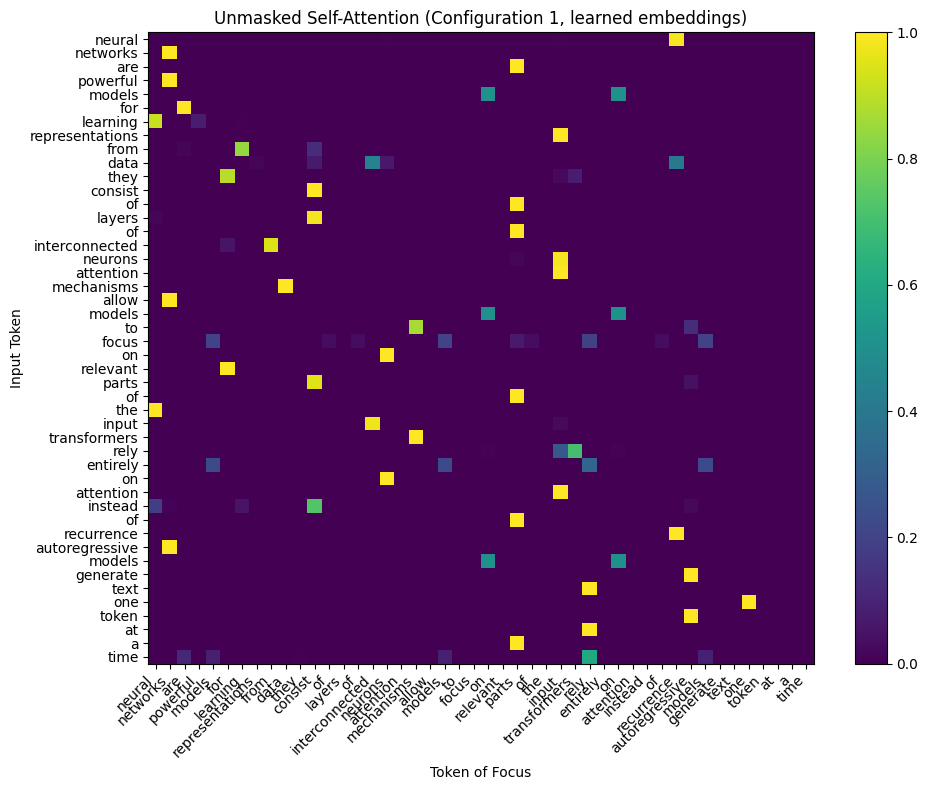

In [29]:
plot_attention(attn_unmasked[0], full_tokens, "Unmasked Self-Attention (Configuration 1, learned embeddings)")

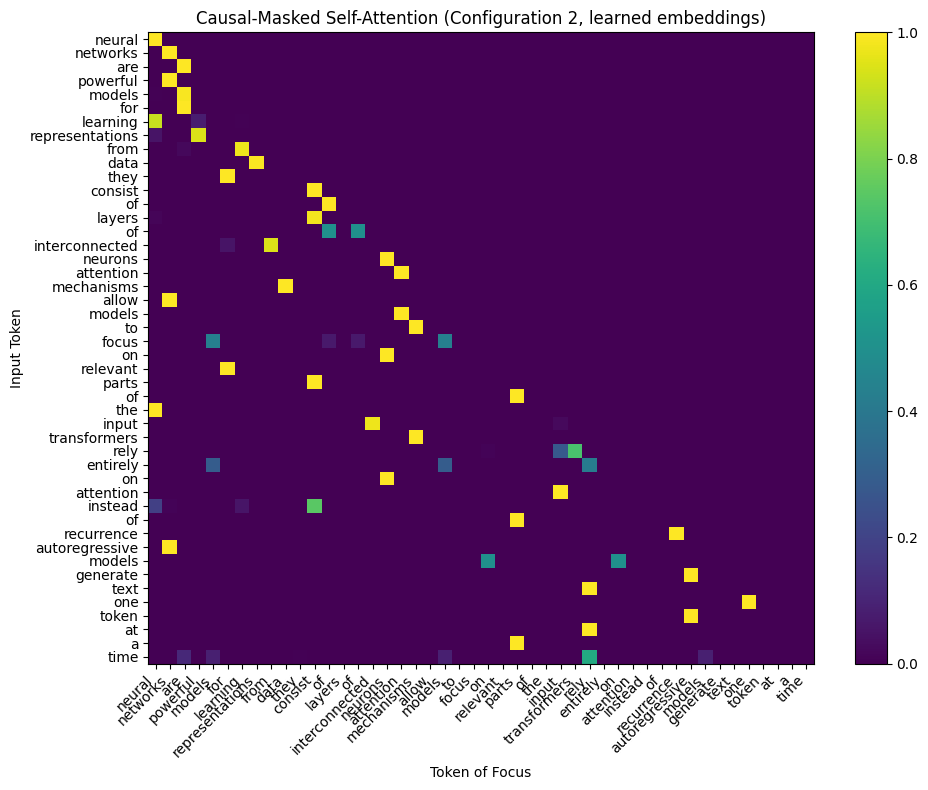

In [30]:
plot_attention(attn_masked[0], full_tokens, "Causal-Masked Self-Attention (Configuration 2, learned embeddings)")

### 2.12 Verification

The assertions below check, directly on the trained model's output, that the implementation is correct
rather than just visually plausible:

- both attention matrices have the expected `[1, T, T]` shape;
- every attention row sums to approximately 1 (softmax was applied correctly);
- the causal mask used for the full sequence is exactly lower-triangular; and
- masked attention assigns (approximately) zero weight to every position above the diagonal — i.e., no
  token ever attends to a future token.

In [31]:
T = len(full_tokens)

# 1) Attention matrices have the expected shape
assert attn_unmasked.shape == (1, T, T), attn_unmasked.shape
assert attn_masked.shape == (1, T, T), attn_masked.shape
print("Shape assertion passed:", tuple(attn_masked.shape))

# 2) Each attention row sums to ~1
row_sums_unmasked = attn_unmasked[0].sum(dim=-1)
row_sums_masked = attn_masked[0].sum(dim=-1)
assert torch.allclose(row_sums_unmasked, torch.ones(T, device=device), atol=1e-4)
assert torch.allclose(row_sums_masked, torch.ones(T, device=device), atol=1e-4)
print("Row-sum assertion passed (min/max):",
      row_sums_masked.min().item(), row_sums_masked.max().item())

# 3) Causal mask is lower triangular
full_mask = make_causal_mask(T, device)
assert torch.equal(full_mask, torch.tril(torch.ones((T, T), device=device)).bool())
print("Causal mask lower-triangular assertion passed")

# 4) Masked future positions have (approximately) zero attention weight
A = attn_masked[0].detach().cpu()
upper = torch.triu(torch.ones_like(A), diagonal=1).bool()
leaked_mass = A[upper].sum().item()
max_future_weight = A[upper].max().item() if upper.any() else 0.0

print("Total attention mass above diagonal (should be ~0):", leaked_mass)
print("Max single future-position weight (should be ~0):", max_future_weight)
assert leaked_mass < 1e-4
assert max_future_weight < 1e-4
print("Causal masking assertion passed: zero weight on all future-token positions")

Shape assertion passed: (1, 46, 46)
Row-sum assertion passed (min/max): 0.9999998807907104 1.000000238418579
Causal mask lower-triangular assertion passed
Total attention mass above diagonal (should be ~0): 0.0
Max single future-position weight (should be ~0): 0.0
Causal masking assertion passed: zero weight on all future-token positions


### 2.13 Unmasked vs. Masked Attention — Summary

Both configurations use the exact same trained embeddings and Q/K/V weights, so any difference between
the two heatmaps is caused only by causal masking, not by different training. In the unmasked heatmap,
every token is free to attend to tokens anywhere in the sentence, including ones that come after it. In
the causal-masked heatmap, the upper-triangular half of the matrix is exactly zero (verified above), so
each token's row only distributes weight over itself and earlier tokens — matching how an autoregressive
decoder must behave when it cannot see the future.